<a href="https://colab.research.google.com/github/dieterheinrich/Pytorch_Colab/blob/main/Pytorch01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import numpy as np

In [ ]:
#!pip list


In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
print(f"device: {device}\n")
type(device)


device: cuda



torch.device

In [5]:
# numpy cpu -> tensor cpu -> tensor gpu
np_array = np.array([1.0, 2.0, 3.0, 4.0])

gpu_tensor_a = torch.tensor(np_array, dtype=torch.float32, device=device)

cpu_tensor = torch.from_numpy(np_array).float() # .float() wechselt zu float32
gpu_tensor_b = cpu_tensor.to(device)

print(f"Option A - Gerät: {gpu_tensor_a.device} | Datentyp: {gpu_tensor_a.dtype}")
print(f"Option B - Gerät: {gpu_tensor_b.device} | Datentyp: {gpu_tensor_b.dtype}\n")


Option A - Gerät: cuda:0 | Datentyp: torch.float32
Option B - Gerät: cuda:0 | Datentyp: torch.float32



In [ ]:
# numpy cpu <- tensor cpu <- tensor gpu

np_zurueck = gpu_tensor_a.cpu().numpy()

print(f"Zurück zu NumPy: {type(np_zurueck)} (Liegt wieder sicher im RAM!)\n")

Zurück zu NumPy: <class 'numpy.ndarray'> (Liegt wieder sicher im RAM!)



In [ ]:
einzel_loss_gpu = torch.tensor([0.4521], device=device)

loss_wert = einzel_loss_gpu.item()

print(f"Normale Python-Zahl: {loss_wert} | Typ: {type(loss_wert)}")

Normale Python-Zahl: 0.45210000872612 | Typ: <class 'float'>


In [21]:
class SimpleLinearRegression:
    def __init__(self, lr=0.01, epochs=10000):
        self.lr = lr
        self.epochs = epochs
        self.w = 0
        self.b = 0
    def fit(self, X, y):
        n = len(X)
        for _ in range(self.epochs):
            y_pred = self.w * X + self.b

            # Gradients
            dw = (-2/n) * sum(X * (y - y_pred))
            db = (-2/n) * sum(y - y_pred)

            # Update parameters
            self.w -= self.lr * dw
            self.b -= self.lr * db
    def predict(self, X):
        return self.w * X + self.b
    def get_param(self):
        return self.w, self.b

# Example usage
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])
model = SimpleLinearRegression()
model.fit(X, y)
param = model.get_param()
print(param)
print(model.predict(np.array([6])))  # ~12

(np.float64(1.9999999999999973), np.float64(8.424360046094841e-15))
[12.]


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X.reshape(-1, 1), y) # X has to be 2D array
param = model.coef_, model.intercept_
print(param)
print(model.predict(np.array([6]).reshape(-1, 1)))  # ~12

(array([2.]), np.float64(0.0))
[12.]


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3
reg = LinearRegression().fit(X, y)
reg.score(X, y)
reg.coef_
reg.intercept_
reg.predict(np.array([[3, 5]]))

(5,)
[1.67298032]
1.1031667106826086


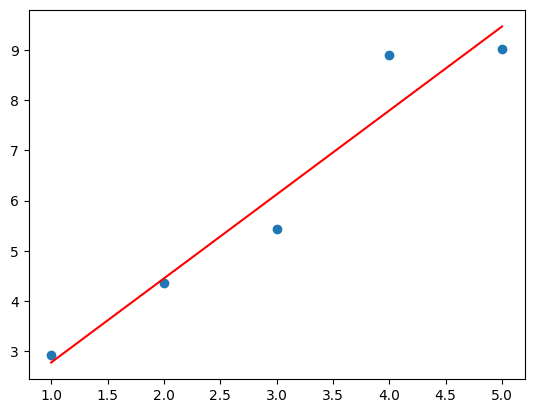

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([1, 2, 3, 4, 5])
print(X.shape)
Y = 2*X + 1*np.random.randn(X.shape[0])
plt.scatter(X, Y)
#plt.show()
model = LinearRegression()
model.fit(X.reshape(-1, 1), Y)
print(model.coef_)
print(model.intercept_)
plt.plot(X, model.predict(X.reshape(-1, 1)), color='red')
plt.show()

In [20]:
import torch
import torch.nn as nn
import numpy as np

class SimpleLinearRegression(nn.Module):
  def __init__(self) -> None:
      super().__init__()
      self.linear_model = nn.Linear(in_features=1, out_features=1)
  def forward(self,x):
      return self.linear_model(x)

model = SimpleLinearRegression() # .to(device) # move to gpu
print(model)
print(model.parameters)

#X = np.array([1, 2, 3, 4, 5])
#Y = 2*X + 1*np.random.randn(X.shape[0])
X = torch.from_numpy(X).float().reshape(-1,1) #.to(device) # move to gpu
y = torch.from_numpy(Y).float().reshape(-1,1) #.to(device) # move to gpu


# model training to come here
learning_rate = 1e-3
#batch_size = 64
epochs = 10

# loss function
loss_fn = nn.MSELoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    model.train()

    pred = model(X)
    loss = loss_fn(pred, y)
    print(f"Loss: {loss.item()}")

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print("Training Done!")

# model weights
with torch.no_grad():
    w = model.linear_model.weight.item()
    b = model.linear_model.bias.item()
    print(f"\nGelerntes Modell: Y = {w:.2f} * X + {b:.2f}")

# model prediction
model.eval()
with torch.no_grad():
    neue_zahl = torch.tensor([[6.0]]) # Muss ebenfalls die Form (1, 1) haben
    vorhersage = model(neue_zahl)
    print(f"Vorhersage für X=6: {vorhersage.item():.4f} (Erwartet wäre ca. 12)")

print('done')




SimpleLinearRegression(
  (linear_model): Linear(in_features=1, out_features=1, bias=True)
)
<bound method Module.parameters of SimpleLinearRegression(
  (linear_model): Linear(in_features=1, out_features=1, bias=True)
)>


TypeError: expected np.ndarray (got Tensor)

In [32]:
import torch

x = torch.randn(3, 3, requires_grad=True)
w = torch.randn(3, 3, requires_grad=True)

# 1. Erste Berechnung
z = torch.matmul(x, w)

# 2. Du "schneidest" z ab
z = z.detach()
print(z.requires_grad)  # Ausgabe: False -> FÜR Z IST ES JETZT AUS.

# 3. Nächste Berechnung mit denselben Gewichten:
neu = torch.matmul(x, w)
print(neu.requires_grad)  # Ausgabe: True -> PYTORCH TRACKT SCHON WIEDER!

neu2 = 2*z
print(neu2.requires_grad)


False
True
False


In [35]:
inp = torch.eye(4, 5, requires_grad=True)
print(inp)
out = (inp+1).pow(2).t()
print(out)
out.backward(torch.ones_like(out), retain_graph=True)
print(f"First call\n{inp.grad}")
out.backward(torch.ones_like(out), retain_graph=True)
print(f"\nSecond call\n{inp.grad}")
inp.grad.zero_()
out.backward(torch.ones_like(out), retain_graph=True)
print(f"\nCall after zeroing gradients\n{inp.grad}")

tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.]], requires_grad=True)
tensor([[4., 1., 1., 1.],
        [1., 4., 1., 1.],
        [1., 1., 4., 1.],
        [1., 1., 1., 4.],
        [1., 1., 1., 1.]], grad_fn=<TBackward0>)
First call
tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.]])

Second call
tensor([[8., 4., 4., 4., 4.],
        [4., 8., 4., 4., 4.],
        [4., 4., 8., 4., 4.],
        [4., 4., 4., 8., 4.]])

Call after zeroing gradients
tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.]])
